<a href="https://colab.research.google.com/github/rakan416/traditional-food-classification/blob/main/Finte_Tuning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kaggle Authentication

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 69 bytes


# Download Dataset

In [2]:
import kagglehub

# Download latest version
DATASET_PATH_FOLDER = kagglehub.competition_download('data-mining-action-2025')

100%|██████████| 366M/366M [00:19<00:00, 19.7MB/s]

Extracting files...


# Preparation

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import wandb
import copy
import cv2
import time
from PIL import Image
from tqdm import tqdm



import timm

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import classification_report, confusion_matrix

## Metadata
Membuat dataframe sebagai metadata setiap gambar

In [4]:
TRAIN_PATH_FOLDER = DATASET_PATH_FOLDER+'/train/train/'
TEST_PATH_FOLDER = DATASET_PATH_FOLDER+'/test/test/'
PROJECT_DRIVE_PATH = '/content/drive/MyDrive/COMPETITION/ACTION (clean)'

list_train_files = os.listdir(TRAIN_PATH_FOLDER)
list_test_files = os.listdir(TEST_PATH_FOLDER)

df_train_files = pd.DataFrame(list_train_files, columns=['filename'])
df_test_files = pd.DataFrame(list_test_files, columns=['filename'])

df_train_files.info()
df_test_files.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  4257 non-null   object
dtypes: object(1)
memory usage: 33.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2057 entries, 0 to 2056
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  2057 non-null   object
dtypes: object(1)
memory usage: 16.2+ KB


### Load Labelled Data
Data ini didapatkan dari hasil semi-supertvised learning dengan total 7 iterasi.

In [5]:
df_labelled_train_files = pd.read_csv(PROJECT_DRIVE_PATH+"/data/clean_model_labeling_07.csv")
df_labelled_train_files

,label,filename
0,Nasi Goreng,30mmyw.jpg
1,Sate Padang,ak4swb.jpg
2,Gudeg,c99aqd.jpg
3,Coto Makassar,jb3t6o.jpg
4,Rendang,1f6ix1.jpg
...,...,...
4006,Ayam Pop,zfwsk9.jpg
4007,Rawon,zm7mdw.jpg
4008,Coto Makassar,ztqgfl.jpg
4009,Ayam Bakar,ztqy3o.jpg


## Preprocessing

### Parameter Initiation

In [8]:
ID2LABEL = {
    0:'Ayam Bakar',
    1:'Ayam Betutu',
    2:'Ayam Goreng',
    3:'Ayam Pop',
    4:'Bakso',
    5:'Coto Makassar',
    6:'Gado Gado',
    7:'Gudeg',
    8:'Nasi Goreng',
    9:'Pempek',
    10:'Rawon',
    11:'Rendang',
    12:'Sate Madura',
    13:'Sate Padang',
    14:'Soto'
}

LABEL2ID = {v: k for k, v in ID2LABEL.items()}

# Input Model Parameter
BATCH_SIZE = 16
IMG_SIZE = 224
MEAN_IMAGENET = [0.485, 0.456, 0.406]
STD_IMAGENET = [0.229, 0.224, 0.225]
NUM_CLASSES = len(LABEL2ID)
SUPPORTED_EXTENTION_FILE = ('.png', '.jpg')

In [14]:
df_TRAIN = df_labelled_train_files.sample(frac=0.9, random_state=42)
df_VAL = df_labelled_train_files.drop(df_TRAIN.index)

print(f"Jumlah data training: {len(df_TRAIN)}")
print(f"Jumlah data validasi: {len(df_VAL)}")

Jumlah data training: 3610
Jumlah data validasi: 401


# Fine-Tuning Model
Fine-Tuning pada model dimulai dari weight pretrained.
- Training Lapisan Head (Transfer Learning)
- Training Full Parameter Model

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


### Build Data Input Pipeline for Training

In [ ]:
class CSVImageDataset(Dataset):

    def __init__(self, dataframe: pd.DataFrame, files_dir: str, transform=None, class_to_idx: dict=None):
        self.data_frame = dataframe
        self.transform = transform
        self.files_dir = files_dir


        if class_to_idx is None:
            sorted_labels = sorted(self.data_frame['label'].unique())
            self.class_to_idx = {label: idx for idx, label in enumerate(sorted_labels)}
            self.idx_to_class = {idx: label for label, idx in self.class_to_idx.items()}
        else:
            self.class_to_idx = class_to_idx
            self.idx_to_class = {idx: label for label, idx in self.class_to_idx.items()}

        self.data_frame['label_idx'] = self.data_frame['label'].map(self.class_to_idx)

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]
        file_name = row['filename']
        img_path = os.path.join(self.files_dir, file_name)


        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            try:
                image = Image.open(img_path.replace('.jpg', '.png')).convert('RGB')
            except FileNotFoundError:
              try:
                image = Image.open(img_path+'.jpg').convert('RGB')
              except FileNotFoundError:
                print(f"ERROR: File tidak ditemukan di {img_path}")
                image = Image.new('RGB', (224, 224), (0, 0, 0))
                return image, -1

        label = row['label_idx']
        if self.transform:
            image = self.transform(image)

        return image, label

#### Input + Augmentation format

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(MEAN_IMAGENET, STD_IMAGENET)
    ]),
    'val': transforms.Compose([
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(MEAN_IMAGENET, STD_IMAGENET)
    ]),
}

In [ ]:
print("Memuat data...")
train_dataset = CSVImageDataset(
    dataframe=df_TRAIN,
    files_dir=TRAIN_PATH_FOLDER,
    transform=data_transforms['train'],
    class_to_idx=LABEL2ID
)

val_dataset = CSVImageDataset(
    dataframe=df_VAL,
    files_dir=TRAIN_PATH_FOLDER,
    transform=data_transforms['val'],
    class_to_idx=LABEL2ID
)

image_datasets = {'train': train_dataset, 'val': val_dataset}


dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
    ),
    'val': DataLoader(
        image_datasets['val'],
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
print("DONE")

Memuat data...
DONE


In [ ]:
print(f"Jumlah kelas: {NUM_CLASSES}")
print(f"Mapping kelas: {LABEL2ID}")
print(f"Jumlah data training: {dataset_sizes['train']}")
print(f"Jumlah data validasi: {dataset_sizes['val']}")

try:
    images, labels = next(iter(dataloaders['train']))
    print(f"\nBentuk batch gambar: {images.shape}") # [B, 3, 224, 224]
    print(f"Bentuk batch label: {labels.shape}")   # [B]
except RuntimeError as e:
    print(f"\nError memuat data: {e}")

Jumlah kelas: 15
Mapping kelas: {'Ayam Bakar': 0, 'Ayam Betutu': 1, 'Ayam Goreng': 2, 'Ayam Pop': 3, 'Bakso': 4, 'Coto Makassar': 5, 'Gado Gado': 6, 'Gudeg': 7, 'Nasi Goreng': 8, 'Pempek': 9, 'Rawon': 10, 'Rendang': 11, 'Sate Madura': 12, 'Sate Padang': 13, 'Soto': 14}
Jumlah data training: 3610
Jumlah data validasi: 401

Bentuk batch gambar: torch.Size([16, 3, 224, 224])
Bentuk batch label: torch.Size([16])


## Transfer Learning

### Load Model

In [ ]:
model_name = 'coatnet_2_rw_224'
# Load Pretrained Model
model = timm.create_model(
    model_name,
    pretrained=True, # False jika transfer learning kedua dan seterusnya
    num_classes=NUM_CLASSES
)

# Move Model to Device (CUDA/GPU)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/296M [00:00<?, ?B/s]

### Train Model

In [ ]:
# Transfer Learning Parameter
LR = 1e-3
NUM_EPOCHS = 15

In [ ]:
for param in model.parameters():
  param.requires_grad = False
for param in model.head.parameters():
  param.requires_grad = True

optimizer = optim.AdamW(model.head.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [ ]:
CONFIG = {
    "architecture":model_name,
    "num_classes": NUM_CLASSES,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer":"AdamW",
    "learning_rate": LR,
    "weight_decay": 'default',
    "eps": 'default',
    "device": device,
    "loss_type":"CrossEntropyLoss",
}

In [ ]:
wandb.init(
    project="action25",
    name="CoAtNet-TL-data7",
    config=CONFIG
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rakan-rd-416 (rakan-explorations) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

In [ ]:
for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for i, (inputs, labels) in enumerate(tqdm(dataloaders[phase], desc=phase), 1):
            inputs = inputs.to(CONFIG['device'])
            labels = labels.to(CONFIG['device'])

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                    if i % 10 == 0:
                        wandb.log({
                            "train_batch/loss": loss.item(),  # Metrik khusus batch
                            "epoch": epoch,                   # Agar sumbu X tetap sinkron
                            "batch_index": i                  # Opsional: untuk debug
                        })

            # Akumulasi statistik untuk hitungan per Epoch
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # --- Log Akhir Epoch (Rata-rata) ---
        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'[{phase}] Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Metrik Epoch (Nama dibedakan: train/loss vs train_batch/loss)
        wandb.log({
            f"{phase}/loss": epoch_loss,       # Contoh: train/loss, val/loss
            f"{phase}/accuracy": epoch_acc.item(),
            "epoch": epoch
        })

        if phase == 'val':
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # Update summary agar muncul di tabel eksperimen luar
                wandb.run.summary["best_accuracy"] = best_acc.item()
                wandb.run.summary["best_loss"] = epoch_loss # Loss pada saat akurasi terbaik
                print(f'*** Model terbaik disimpan! Acc: {best_acc:.4f} ***')

print(f'Best val Acc: {best_acc:4f}')


Epoch 1/15
----------


train: 100%|██████████| 226/226 [01:05<00:00,  3.48it/s]


[train] Loss: 1.2835 Acc: 0.5906


val: 100%|██████████| 26/26 [00:08<00:00,  3.05it/s]


[val] Loss: 0.6934 Acc: 0.7606
*** Model terbaik disimpan! Acc: 0.7606 ***

Epoch 2/15
----------


...

[val] Loss: 0.4575 Acc: 0.8579

Epoch 15/15
----------


train: 100%|██████████| 226/226 [01:11<00:00,  3.17it/s]


[train] Loss: 0.5776 Acc: 0.8255


val: 100%|██████████| 26/26 [00:08<00:00,  3.08it/s]

[val] Loss: 0.4221 Acc: 0.8529
Best val Acc: 0.870324


### Save Training Result

In [ ]:
torch.save(model.state_dict(), PROJECT_DRIVE_PATH+'/model/CoatNet2-TL-Data7.pth')

In [ ]:
artifact = wandb.Artifact(
    name="CoAtNet2-TL-Data7",
    type="model",
    description="Model CoAtNet2 yang fine-tune head only dengan data labeling ke-7"
)

wandb.log_artifact(artifact)
wandb.finish()

batch_index,▁▃▄▅▆▅▇▂▇▃▆▇▁▂▂▄▄▆▁▇▆▇▂▄▅▄▄▇▂▅▆▂▇█▃▆▆▁▄▆
epoch,▁▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▇▇▇▇▇▇▇▇█
train/accuracy,▁▅▆▇▆▇▇▇▇██████
train/loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
train_batch/loss,▇█▄▄▃▅▅▆▂▇▄▃▂▂▂▄▄▃▃▇▁▃▂▄▃▆▅▃▃▃▂▃▄▃▅▅▂▃▃▆
val/accuracy,▁▆▆█▇███▇▇▇▇▆▇▇
val/loss,█▅▃▂▃▁▁▂▂▁▁▂▂▃▂
batch_index,220
best_accuracy,0.87032
best_loss,0.42771
epoch,14


## Full Fine-Tuning

### Load Model

In [ ]:
model_name = 'coatnet_2_rw_224'
# Load Pretrained Model
model = timm.create_model(
    model_name,
    pretrained=False,
    num_classes=NUM_CLASSES
)

model.load_state_dict(
    state_dict= torch.load(
        PROJECT_DRIVE_PATH+'/model/CoatNet2-TL-Data7.pth',
        map_location=torch.device(device)
    )
)

# Move Model to Device (CUDA/GPU)
model = model.to(device)

### Train Model

In [ ]:
# Transfer Learning Parameter
LR = 1e-5
NUM_EPOCHS = 30

In [ ]:
for param in model.parameters():
  param.requires_grad = True


optimizer = optim.AdamW(model.head.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',      # 'min' karena kita memantau loss agar turun
    factor=0.1,      # LR baru = LR lama * 0.1
    patience=5,      # Toleransi 3 epoch tanpa perbaikan loss
)


In [ ]:
CONFIG = {
    "architecture":model_name,
    "num_classes": NUM_CLASSES,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer":"AdamW",
    "learning_rate": LR,
    "weight_decay": 'default',
    "eps": 'default',
    "device": device,
    "LR_scheduler":"ReduceLROnPlateau",
    "LR_scheduler_param":{
        "mode":"min",
        "factor":0.1,
        "patience":5,
    },
    "loss_type":"CrossEntropyLoss",
}

In [ ]:
wandb.init(
    project="action25",
    name="CoAtNet-FullFT-data7",
    config=CONFIG
)

In [ ]:
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

In [ ]:
for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for i, (inputs, labels) in enumerate(tqdm(dataloaders[phase], desc=phase), 1):
            inputs = inputs.to(CONFIG['device'])
            labels = labels.to(CONFIG['device'])

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                    if i % 10 == 0:
                        wandb.log({
                            "train_batch/loss": loss.item(),  # Metrik khusus batch
                            "epoch": epoch,                   # Agar sumbu X tetap sinkron
                            "batch_index": i                  # Opsional: untuk debug
                        })

            # Akumulasi statistik untuk hitungan per Epoch
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # --- Log Akhir Epoch (Rata-rata) ---
        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'[{phase}] Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Metrik Epoch (Nama dibedakan: train/loss vs train_batch/loss)
        wandb.log({
            f"{phase}/loss": epoch_loss,       # Contoh: train/loss, val/loss
            f"{phase}/accuracy": epoch_acc.item(),
            "epoch": epoch
        })

        if phase == 'val':
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                # Update summary agar muncul di tabel eksperimen luar
                wandb.run.summary["best_accuracy"] = best_acc.item()
                wandb.run.summary["best_loss"] = epoch_loss # Loss pada saat akurasi terbaik
                print(f'*** Model terbaik disimpan! Acc: {best_acc:.4f} ***')

            scheduler.step(epoch_loss)
            wandb.log({"learning_rate": optimizer.param_groups[0]['lr']})

print(f'Best val Acc: {best_acc:4f}')


Epoch 1/30
----------


train: 100%|██████████| 226/226 [03:05<00:00,  1.22it/s]


[train] Loss: 0.5396 Acc: 0.8307


val: 100%|██████████| 26/26 [00:08<00:00,  2.99it/s]


[val] Loss: 0.3753 Acc: 0.8753
*** Model terbaik disimpan! Acc: 0.8753 ***

Epoch 2/30
----------


...

[val] Loss: 0.3417 Acc: 0.8878

Epoch 30/30
----------


train: 100%|██████████| 226/226 [03:04<00:00,  1.23it/s]


[train] Loss: 0.4540 Acc: 0.8582


val: 100%|██████████| 26/26 [00:08<00:00,  3.07it/s]

[val] Loss: 0.3373 Acc: 0.8928
Best val Acc: 0.900249


### Save Training Result

In [ ]:
torch.save(model.state_dict(), PROJECT_DRIVE_PATH+'/model/CoatNet2-FullFT-Data7.pth')

In [ ]:
artifact = wandb.Artifact(
    name="CoAtNet2-FullFT-Data7",
    type="model",
    description="Model CoAtNet2 yang di fine-tune secara full dengan data labeling ke-7"
)

wandb.log_artifact(artifact)
wandb.finish()

batch_index,██▇█▃▅█▅▆█▅▆▁▅▆▄▃▅▆█▃▆▃▄▆▄█▅▅▂▇▄█▅▂▁▂▆▂▆
epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
learning_rate,██████████████████████▂▂▂▂▂▂▂▁
train/accuracy,▁▂▅▅▃▃▆▅▅▂▅▇▇▅▅▅▄▆▄▅▄▆▇▇▇▅▇▇██
train/loss,██▄▅▆█▅▅▅▇▃▂▂▂▃▄▄▄▄▃▅▂▂▂▂▁▂▂▂▁
train_batch/loss,▄▃▃▃▃▅▄▄▁▄▃▁▃▃▁▄▅▃▅▃▃▅▄▆▂▁▂▁▅▇▆▄▂▄▅▃▃█▂▃
val/accuracy,▂▃▁▁▃▄▅▂▆▅▅▂▆█▄▄▆▃▃█▅▃▄▅▃▅▆▃▅▆
val/loss,▇██▆█▇▆▅▅▃▃▃▅▅▅▄▃▃▃▃▃▃▃▁▅▃▃▄▃▃
batch_index,220
best_accuracy,0.90025
best_loss,0.35412


# Model Evaluation

## Load Model

In [10]:
model_name = 'coatnet_2_rw_224'
# Load Pretrained Model
model = timm.create_model(
    model_name,
    pretrained=False,
    num_classes=NUM_CLASSES
)

model.load_state_dict(
    state_dict= torch.load(
        PROJECT_DRIVE_PATH+'/model/CoatNet2-FullFT-Data7.pth',
        map_location=torch.device(device)
    )
)

# Move Model to Device (CUDA/GPU)
model = model.to(device)

## Input Pipeline

In [11]:
input_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_IMAGENET, STD_IMAGENET)
])

In [12]:
class ImageDataInput(Dataset):

    def __init__(self, filename_data: pd.DataFrame, files_dir: str, class_to_idx: dict, transform=None, except_filename: pd.DataFrame = None):
        self.filename_data = filename_data
        self.transform = transform
        self.files_dir = files_dir

        if except_filename is not None:
            self.data_input = self.filename_data[~self.filename_data['filename'].isin(except_filename['filename'])].reset_index(drop=True)
        else:
            self.data_input = self.filename_data

    def __len__(self):
        return len(self.data_input)

    def __getitem__(self, idx):
        row = self.data_input.iloc[idx]
        filename = row['filename']
        img_path = os.path.join(self.files_dir, filename)

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"ERROR di {img_path}:\n\n{e}")
            return image, filename

        if self.transform:
            image = self.transform(image)

        return image, filename

In [15]:
data_input = ImageDataInput(
    filename_data= df_VAL,
    files_dir=TRAIN_PATH_FOLDER,
    class_to_idx=LABEL2ID,
    transform=input_transforms,
    except_filename=None
)

dataloader = DataLoader(
    data_input,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## Model Prediction

In [16]:
def predict_dataset(dataloader, path_dir):
  model.eval()
  results = []

  print(f"Memulai inferensi pada folder: {path_dir}...")
  with torch.no_grad():
      for images, filenames in tqdm(dataloader):

          try:
              # Dapatkan output (logits) dari model
              images = images.to(device)
              outputs = model(images)

              # --- Konversi Logits ke Probabilitas (Confidence) ---
              probabilities = F.softmax(outputs, dim=1) # 'dim=1' karena outputnya [batch_size, num_classes]
              confidences, pred_idxs = torch.max(probabilities, 1) # Dapatkan confidence dan index kelas tertinggi

              # Pindahkan hasil kembali ke CPU dan ubah ke numpy array agar mudah diekstrak
              confidences = confidences.cpu().numpy()
              pred_idxs = pred_idxs.cpu().numpy()

              # Tambahkan ke list hasil
              for i in range(len(filenames)):
                  results.append({
                      'filename': filenames[i],
                      'label': ID2LABEL[pred_idxs[i]],
                      'confident': float(confidences[i])
                  })

          except Exception as e:
              raise

  # Konversi list hasil ke DataFrame
  df_result_prediction = pd.DataFrame(results)
  df_result_prediction.info()

  return df_result_prediction

In [17]:
df_result_prediction = predict_dataset(dataloader, TRAIN_PATH_FOLDER)

Memulai inferensi pada folder: /root/.cache/kagglehub/competitions/data-mining-action-2025/train/train/...


100%|██████████| 26/26 [00:08<00:00,  3.03it/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   filename   401 non-null    object 
 1   label      401 non-null    object 
 2   confident  401 non-null    float64
dtypes: float64(1), object(2)
memory usage: 9.5+ KB


## Evaluation

In [72]:
# classification report
y_pred = df_result_prediction['label']
y_true = df_VAL['label']

print(classification_report(y_true, y_pred))

               precision    recall  f1-score   support

   Ayam Bakar       0.88      0.74      0.81        31
  Ayam Betutu       0.92      0.82      0.87        28
  Ayam Goreng       0.74      0.87      0.80        30
     Ayam Pop       1.00      0.96      0.98        23
        Bakso       1.00      1.00      1.00        22
Coto Makassar       0.91      0.94      0.92        31
    Gado Gado       0.94      0.94      0.94        32
        Gudeg       0.88      0.88      0.88        26
  Nasi Goreng       0.97      0.93      0.95        30
       Pempek       1.00      1.00      1.00        22
        Rawon       0.88      0.84      0.86        25
      Rendang       0.89      0.96      0.92        25
  Sate Madura       0.91      0.91      0.91        33
  Sate Padang       0.90      0.93      0.92        30
         Soto       0.80      0.92      0.86        13

     accuracy                           0.91       401
    macro avg       0.91      0.91      0.91       401
 weighte

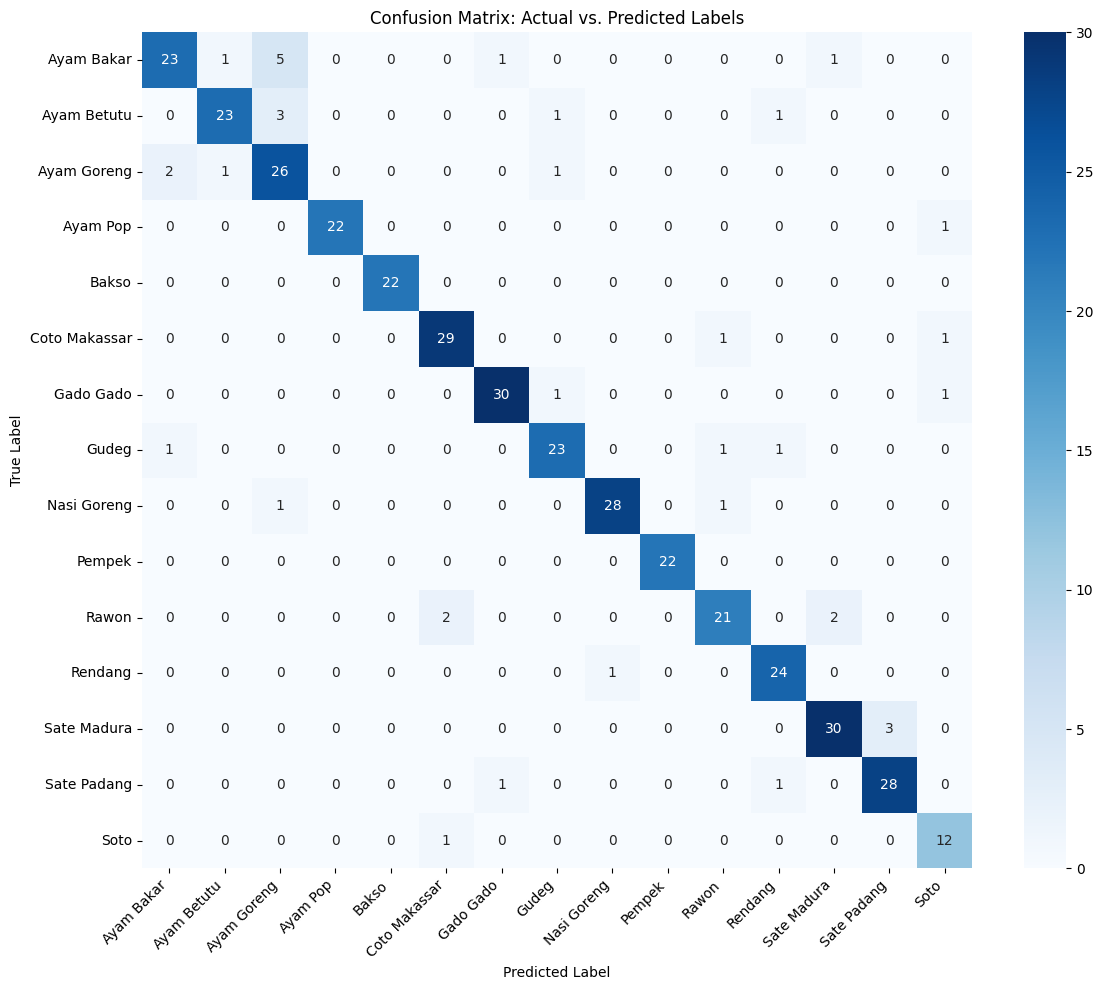

In [73]:
# Get the class labels
labels = list(LABEL2ID.keys())

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Create a DataFrame for better visualization with seaborn
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix: Actual vs. Predicted Labels')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [74]:
# Rename the 'label' column in df_VAL to 'true_label' to avoid confusion
df_eval = df_VAL.rename(columns={'label': 'true_label'})

# Merge df_eval and df_result_prediction on 'filename'
df_eval = pd.merge(
    df_eval,
    df_result_prediction,
    on='filename',
    how='inner'
)

missclassified = df_eval[df_eval['true_label'] != df_eval['label']].reset_index(drop=True)
missclassified.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   true_label  38 non-null     object 
 1   filename    38 non-null     object 
 2   label       38 non-null     object 
 3   confident   38 non-null     float64
dtypes: float64(1), object(3)
memory usage: 1.3+ KB


### Misclassified Predictions with High Confidence (Confidence > Threshold)

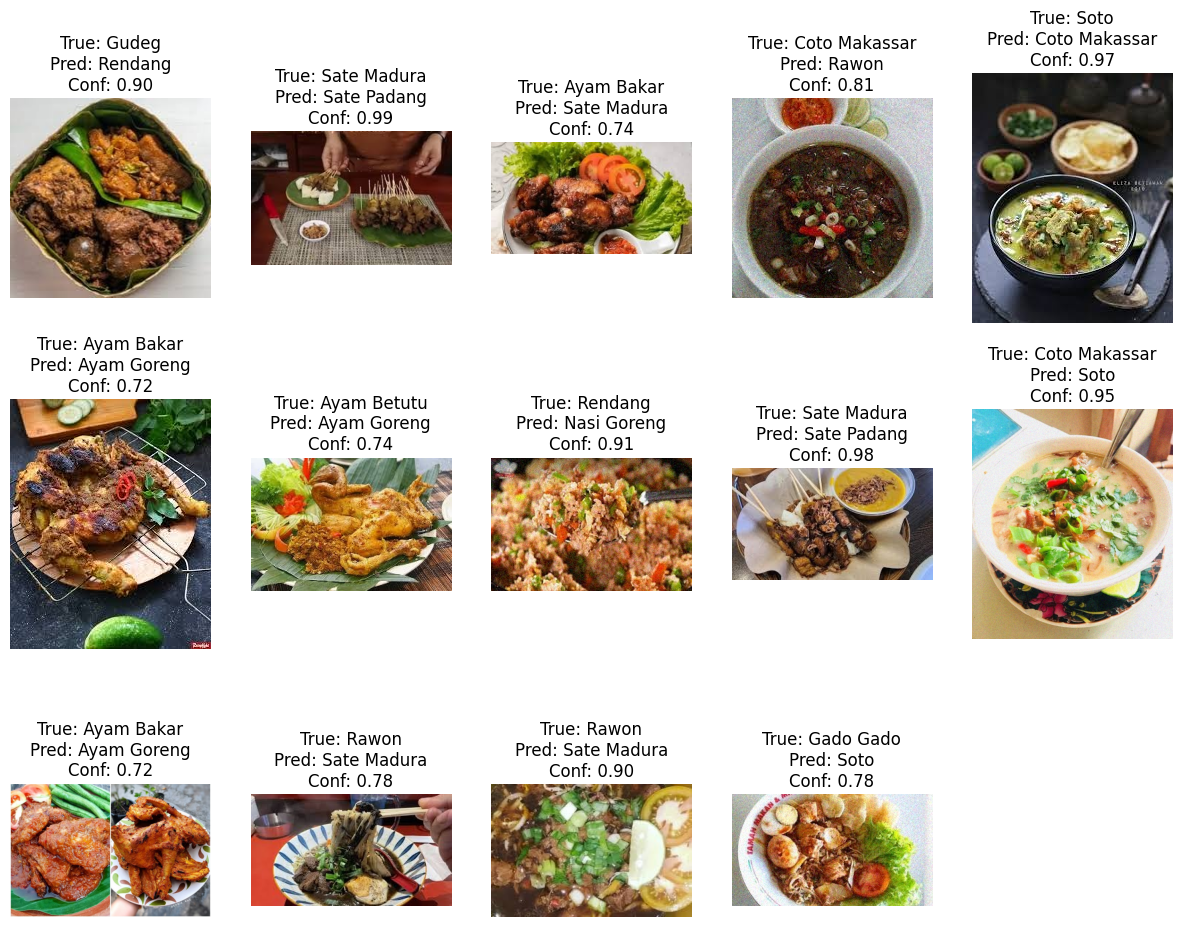

In [75]:
# Filter for misclassified predictions where confidence is > threshold_high
threshold_high = 0.7
misclassified_high_confidence = missclassified[missclassified['confident'] > threshold_high].reset_index(drop=True)


nrow = (len(misclassified_high_confidence) // 5) + 1
ncol = 5

plt.figure(figsize=(15, nrow*4))
for plot_idx, (df_index, row) in enumerate(misclassified_high_confidence.iterrows()):
    filename = row['filename']
    true_label = row['true_label']
    predicted_label = row['label']
    confidence = row['confident']

    img_path = os.path.join(TRAIN_PATH_FOLDER, filename)

    try:
        image = Image.open(img_path).convert('RGB')
    except FileNotFoundError:
        try:
            # Try with a different extension if not found
            image = Image.open(img_path.replace('.jpg', '.png')).convert('RGB')
        except FileNotFoundError:
            print(f"Warning: Image file not found for {filename}. Skipping.")
            continue

    plt.subplot(nrow, ncol, plot_idx+1)
    plt.imshow(image)
    plt.title(f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}")
    plt.axis('off')

# plt.tight_layout()
plt.show()

### Displaying Top-5 Predicted Candidates for an Image

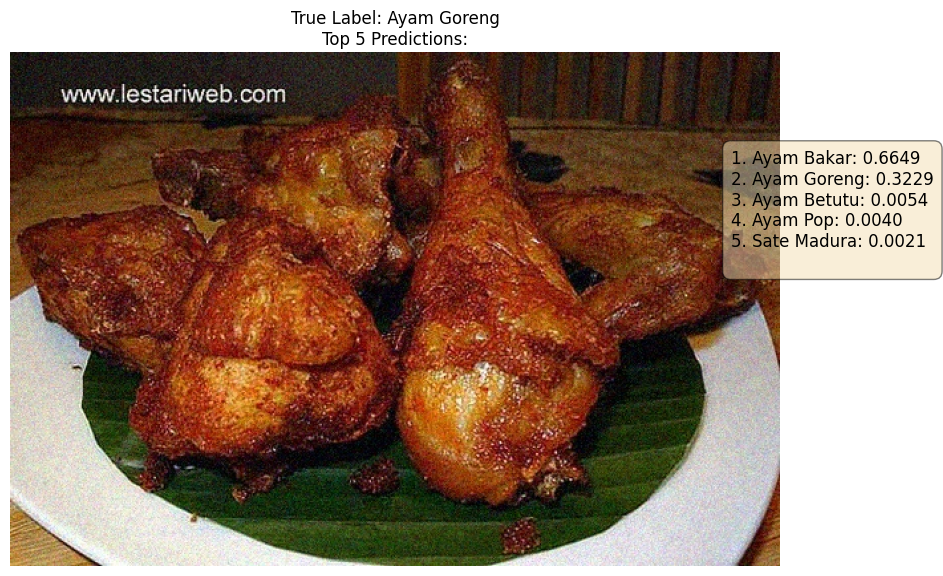

In [76]:
def display_top_5_predictions(filename, true_label, img_dir):
  # Pick a sample image from the validation set
  sample_filename = filename
  sample_true_label = true_label
  img_path = os.path.join(img_dir, sample_filename)

  # Load the image
  try:
      image = Image.open(img_path).convert('RGB')
  except FileNotFoundError:
      try:
          image = Image.open(img_path.replace('.jpg', '.png')).convert('RGB')
      except FileNotFoundError:
          print(f"ERROR: File not found at {img_path} or {img_path.replace('.jpg', '.png')}")
          # Create a blank image to avoid errors if file not found
          image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))

  # Preprocess the image
  input_tensor = input_transforms(image).unsqueeze(0) # Add batch dimension

  # Move model to evaluation mode and device
  model.eval()
  input_tensor = input_tensor.to(device)

  # Make prediction
  with torch.no_grad():
      outputs = model(input_tensor)
      probabilities = F.softmax(outputs, dim=1)

  # Get top 5 predictions
  top5_prob, top5_idx = torch.topk(probabilities, 5)

  top5_prob = top5_prob.squeeze().cpu().numpy()
  top5_idx = top5_idx.squeeze().cpu().numpy()

  # Display the image and top 5 predictions
  plt.figure(figsize=(8, 8))
  plt.imshow(image)
  plt.title(f"True Label: {sample_true_label}\nTop 5 Predictions:")
  plt.axis('off')

  # Create a text box for predictions
  predictions_text = ""
  for i in range(len(top5_prob)):
      label = ID2LABEL[top5_idx[i]]
      confidence = top5_prob[i]
      predictions_text += f"{i+1}. {label}: {confidence:.4f}\n"

  plt.figtext(0.92, 0.7, predictions_text, ha="left", va="top", fontsize=12,
              bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5))

  plt.tight_layout()
  plt.show()

display_top_5_predictions(
    filename= missclassified.loc[0, 'filename'],
    true_label= missclassified.loc[0, 'true_label'],
    img_dir=TRAIN_PATH_FOLDER
)

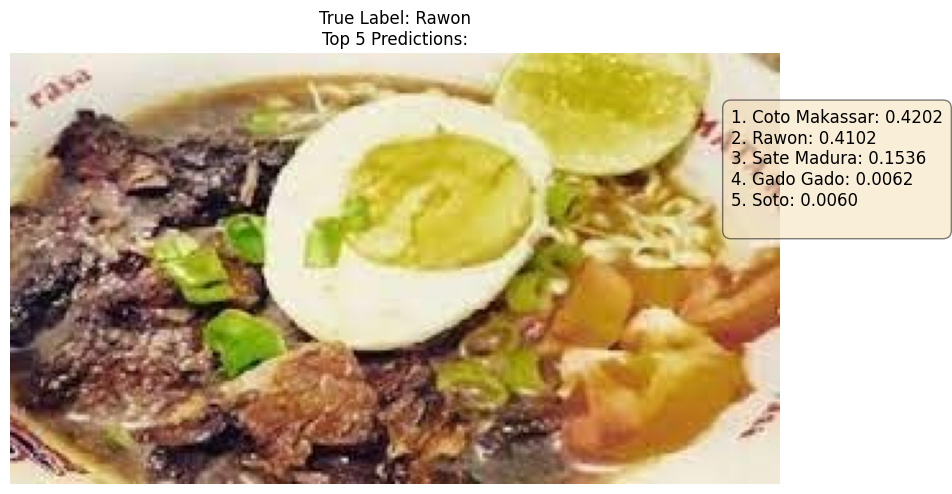

In [78]:
threshold_low = 0.5
missclassified_low_confidence = missclassified[missclassified['confident'] < threshold_low].reset_index(drop=True)

display_top_5_predictions(
    filename= missclassified_low_confidence.loc[0, 'filename'],
    true_label= missclassified_low_confidence.loc[0, 'true_label'],
    img_dir=TRAIN_PATH_FOLDER
)

# Predict Data Test for Kaggle Submission

## Load Model

In [ ]:
model_name = 'coatnet_2_rw_224'
# Load Pretrained Model
model = timm.create_model(
    model_name,
    pretrained=False,
    num_classes=NUM_CLASSES
)

model.load_state_dict(
    state_dict= torch.load(
        PROJECT_DRIVE_PATH+'/model/CoatNet2-FullFT-Data7.pth',
        map_location=torch.device(device)
    )
)

# Move Model to Device (CUDA/GPU)
model = model.to(device)

## Load Submission Template

In [18]:
df_submission = pd.read_csv(DATASET_PATH_FOLDER+'/test.csv')
df_submission

,ID,label
0,1,Ayam Pop
1,2,Sate Madura
2,3,Rawon
3,4,Ayam Bakar
4,5,Gudeg
...,...,...
2052,2053,Soto
2053,2054,Sate Padang
2054,2055,Rendang
2055,2056,Ayam Pop


## Predict data test

In [19]:
df_test_files.sort_values(by='filename', inplace=True)
data_input = ImageDataInput(
    filename_data= df_test_files,
    files_dir=TEST_PATH_FOLDER,
    class_to_idx=LABEL2ID,
    transform=input_transforms,
    except_filename=None
)

dataloader = DataLoader(
    data_input,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [20]:
df_prediction_result = predict_dataset(dataloader, TEST_PATH_FOLDER)

Memulai inferensi pada folder: /root/.cache/kagglehub/competitions/data-mining-action-2025/test/test/...


100%|██████████| 129/129 [00:38<00:00,  3.35it/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2057 entries, 0 to 2056
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   filename   2057 non-null   object 
 1   label      2057 non-null   object 
 2   confident  2057 non-null   float64
dtypes: float64(1), object(2)
memory usage: 48.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2057 entries, 0 to 2056
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   filename   2057 non-null   object 
 1   label      2057 non-null   object 
 2   confident  2057 non-null   float64
dtypes: float64(1), object(2)
memory usage: 48.3+ KB


## Save Prediction in submission template

In [21]:
df_submission['label'] = df_prediction_result['label'].values

In [23]:
df_submission.to_csv(PROJECT_DRIVE_PATH+'/submission/CoAtNet-2-rw-224_pred-001.csv', index=False)